# WARNING
This will create a folder dataset, different to the main notebook.ipynb.

So be warned, for your pc could suffer the concequeses.


Fixes will be on the way, eventually  ❀ 

In [2]:
# Suppress TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# un po' di setup
import io
import math
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from six.moves import urllib


Guarda diva un po' di analisi del dataset. Prima di tutto scarichiamo il dataset, spero funzioni...

In [3]:
FLOWERS_DIR = './flower_photos'

def download_images():
  """If the images aren't already downloaded, save them to FLOWERS_DIR."""
  if not os.path.exists(FLOWERS_DIR):
    DOWNLOAD_URL = 'http://download.tensorflow.org/example_images/flower_photos.tgz'
    print('Downloading flower images from %s...' % DOWNLOAD_URL)
    urllib.request.urlretrieve(DOWNLOAD_URL, 'flower_photos.tgz')
    !tar xfz flower_photos.tgz
  print('Flower photos are located in %s' % FLOWERS_DIR)

download_images()

Flower photos are located in ./flower_photos


# Load Dataset
Carico il dataset Flowers, per determinare le classi obiettivo e printare statistiche su di esso

Classes found: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Total images: 3670
Total classes: 5

Images per class:
  daisy: 633
  dandelion: 898
  roses: 641
  sunflowers: 699
  tulips: 799


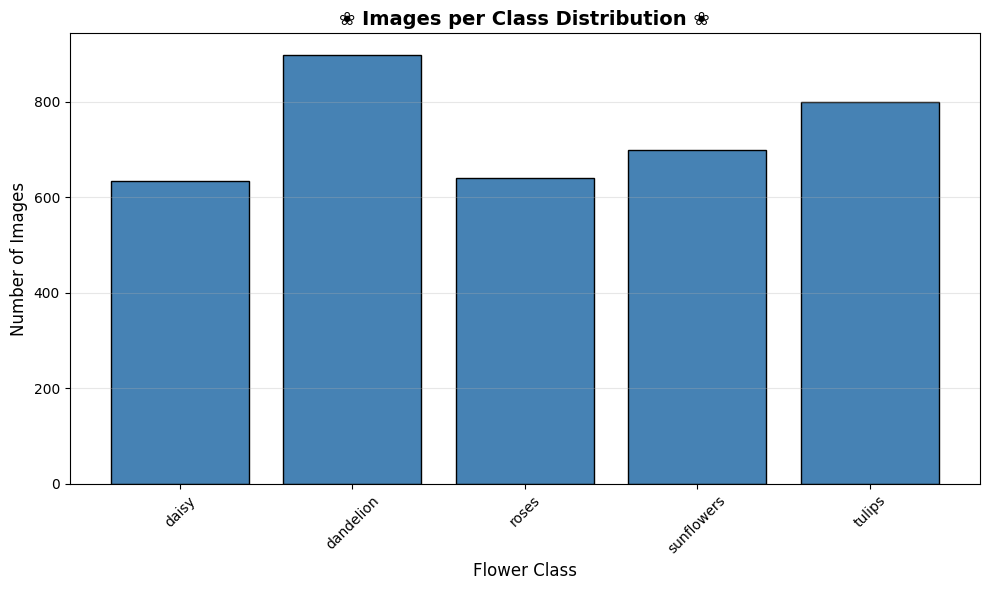

In [4]:
# Load dataset information
CLASSES = sorted([d.name for d in Path(FLOWERS_DIR).iterdir() if d.is_dir() and not d.name.startswith('.')])
print(f"Classes found: {CLASSES}\n")

# Load image paths and labels
EXAMPLES = []
for label, flower_class in enumerate(CLASSES):
    class_dir = Path(FLOWERS_DIR) / flower_class
    for image_path in sorted(class_dir.glob('*.jpg')):
        EXAMPLES.append((str(image_path), label))

# Print dataset statistics
print(f"Total images: {len(EXAMPLES)}")
print(f"Total classes: {len(CLASSES)}")
print("\nImages per class:")
for flower_class in CLASSES:
    count = sum(1 for _, label in EXAMPLES if CLASSES[label] == flower_class)
    print(f"  {flower_class}: {count}")


# Visualize class distribution as histogram
class_counts = []
for flower_class in CLASSES:
    count = sum(1 for _, label in EXAMPLES if CLASSES[label] == flower_class)
    class_counts.append(count)

plt.figure(figsize=(10, 6))
plt.bar(CLASSES, class_counts, color='steelblue', edgecolor='black')
plt.xlabel('Flower Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('❀ Images per Class Distribution ❀', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Informazioni Aggiuntive
Visualizziamo degli esempi e forse qualcos'altro

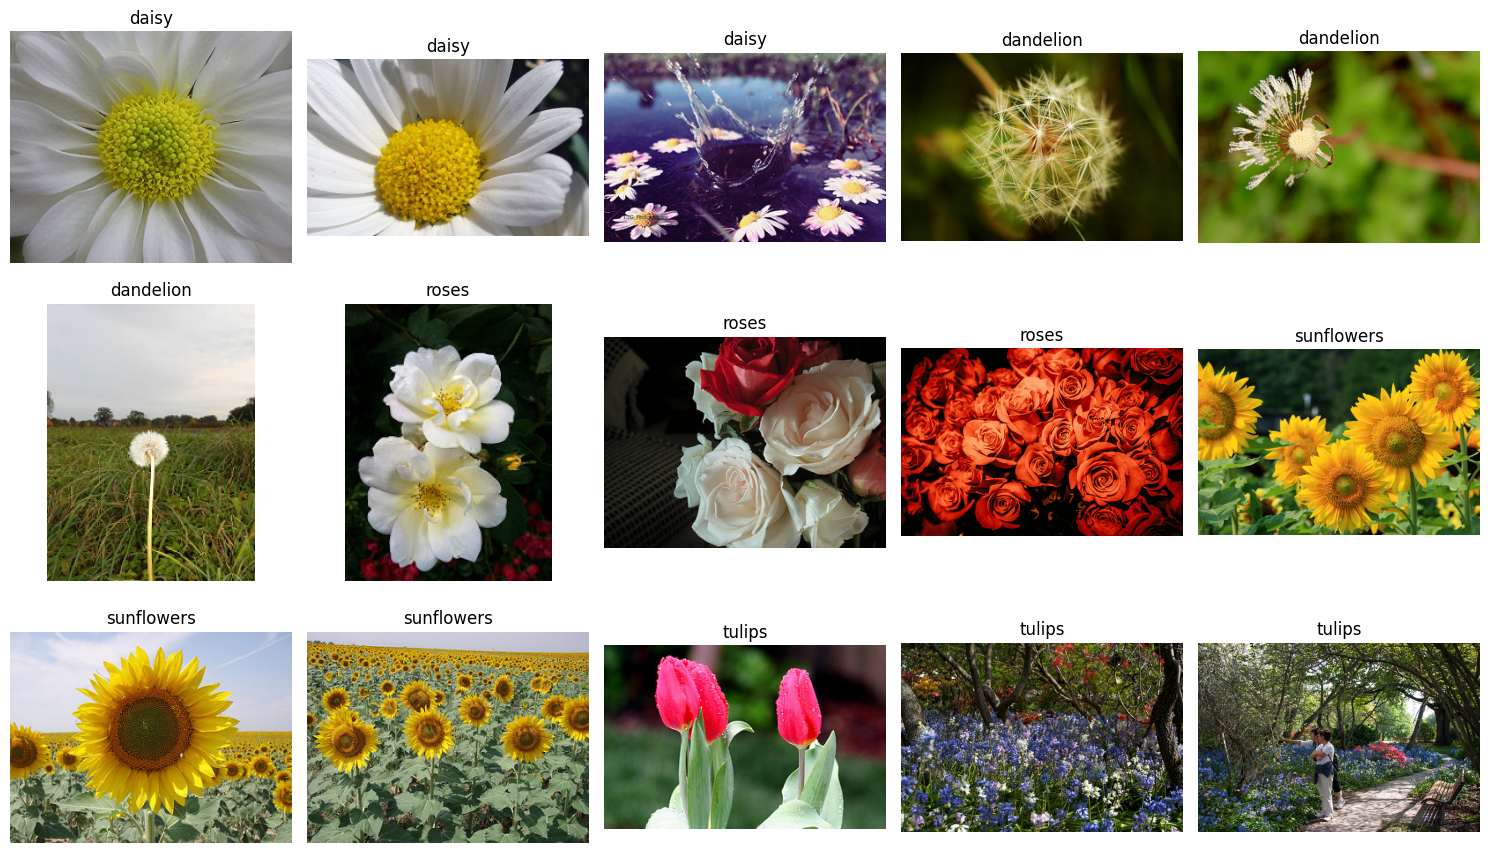

In [5]:
def get_label(example):
  """Get the label (number) for given example."""
  return example[1]

def get_class(example):
  """Get the class (string) of given example."""
  return CLASSES[get_label(example)]

def get_image(example):
  """Get image as np.array of pixels for given example."""
  image_path = example[0]
  return plt.imread(image_path)

def display_images(images_and_classes, cols=5):
  """Display given images and their labels in a grid."""
  rows = int(math.ceil(len(images_and_classes) / cols))
  fig = plt.figure()
  fig.set_size_inches(cols * 3, rows * 3)
  for i, (image, flower_class) in enumerate(images_and_classes):
    plt.subplot(rows, cols, i + 1)
    plt.axis('off')
    plt.imshow(image)
    plt.title(flower_class)
  plt.tight_layout()
  plt.show()

# Display 15 random images
NUM_IMAGES = 15
samples_per_class = NUM_IMAGES // len(CLASSES)

balanced_examples = []
for label in range(len(CLASSES)):
    class_examples = [ex for ex in EXAMPLES if get_label(ex) == label]
    balanced_examples.extend(class_examples[:samples_per_class])

display_images([(get_image(example), get_class(example))
              for example in balanced_examples])
